<div style="border: 1px solid #e1e4e8; border-radius: 12px; padding: 32px; font-family: -apple-system,BlinkMacSystemFont,Segoe UI,Helvetica,Arial,sans-serif; background-color: #fafbfc;">

<div align="center">

<h1 style="margin-bottom: 8px; color: #24292e; font-size: 32px; font-weight: 700; letter-spacing: -0.5px;">
📈 Time Series & Econometric Modeling
</h1>

<p style="margin-top: 0; color: #586069; font-size: 16px; font-weight: 400;">
Evaluating Macroeconomic Drivers of the US Equity Market
</p>

<table style="border: none; border-collapse: collapse; margin-top: 20px; margin-bottom: 12px; background: transparent;">
<tr style="border: none; background: transparent;">

<td align="center" style="padding: 4px 24px; border: none; border-right: 1px solid #e1e4e8;">
<b style="color: #0366d6; font-size: 12px; text-transform: uppercase; letter-spacing: 1px;">Domain</b><br>
<span style="color: #24292e; font-size: 14px; font-weight: 500;">Financial Econometrics</span>
</td>

<td align="center" style="padding: 4px 24px; border: none; border-right: 1px solid #e1e4e8;">
<b style="color: #0366d6; font-size: 12px; text-transform: uppercase; letter-spacing: 1px;">Target</b><br>
<span style="color: #24292e; font-size: 14px; font-weight: 500;">S&P 500 Index</span>
</td>

<td align="center" style="padding: 4px 24px; border: none; border-right: 1px solid #e1e4e8;">
<b style="color: #0366d6; font-size: 12px; text-transform: uppercase; letter-spacing: 1px;">Data Ingestion</b><br>
<span style="color: #24292e; font-size: 14px; font-weight: 500;">FRED • Yahoo Finance</span>
</td>

<td align="center" style="padding: 4px 24px; border: none;">
<b style="color: #0366d6; font-size: 12px; text-transform: uppercase; letter-spacing: 1px;">Frameworks</b><br>
<span style="color: #24292e; font-size: 14px; font-weight: 500;">OLS • Lasso/Ridge • MLP</span>
</td>

</tr>
</table>

<hr style="border: 0; border-top: 1px solid #e1e4e8; margin: 24px 0 16px 0;">

<p style="color: #586069; font-size: 13px; margin: 0; letter-spacing: 0.5px; font-weight: 500;">
Research Notebook • Quantitative Finance • Machine Learning • Macroeconomic Analysis
</p>

</div>

</div>
---

# 1. Project Overview

This project builds an automated end-to-end quantitative pipeline designed to model, analyze, and predict the **S&P 500 Index** utilizing fundamental macroeconomic indicators. The pipeline ingests live observations from the **FRED (Federal Reserve Economic Data) API** and the **Yahoo Finance API**, consolidating them into a unified, monthly-frequency dataset starting from the year 2000.

By leveraging rigorous time-series diagnostics alongside machine learning architectures, we evaluate how monetary policy actions, inflationary pressures, labor market dynamics, and debt market structures collectively impact risk assets and equity valuations.

---

# 2. Project Roadmap

This notebook is structured sequentially to reflect professional quantitative research workflows:

*   **[Active] Phase 1: Data Ingestion & API Pipelines**
    *   Secure environment configuration (`.env`).
    *   API rate limit management and programmatic fetching.
    *   Temporal alignment, forward-filling, and unified monthly resampling.
*   **[Pending] Phase 2: Exploratory Data Analysis & Statistical Diagnostics**
    *   Stationarity checks via Augmented Dickey-Fuller (ADF) tests.
    *   Multicollinearity diagnostics using Variance Inflation Factor (VIF).
    *   Granger Causality testing to analyze lead-lag structures.
*   **[Pending] Phase 3: Feature Engineering & Transformation**
    *   Log-returns, rolling realized volatility, and inflation momentum features.
    *   Stationary transformation of non-stationary covariates.
    *   Lag structures to capture delayed policy transmission mechanisms.
*   **[Pending] Phase 4: Model Training & Time-Series Evaluation**
    *   Baseline Ordinary Least Squares (OLS) regression.
    *   Regularized models (Lasso, Ridge, ElasticNet) to prevent overfitting on low-sample regimes.
    *   Multilayer Perceptron (MLP) neural networks for non-linear pattern capture.
    *   Backtesting using expanding-window walk-forward validation (`TimeSeriesSplit`).

---

# 3. Data Dictionary & Theoretical Rationale

*   **Effective Federal Funds Rate (`FEDFUNDS`)**: Represents the absolute cost of capital and the risk-free rate ($R_f$). It serves as the primary tool of monetary policy; interest rate hikes increase borrowing costs, dampening corporate margins and stock valuations.
*   **Consumer Price Index (`CPIAUCSL`)**: Reflects consumer inflation levels. Persistent inflation erodes real corporate earnings, alters consumer spending patterns, and forces the central bank into hawkish interventions.
*   **Yield Curve Spread (`T10Y2Y`)**: The yield spread between the 10-Year and 2-Year US Treasury bonds. A widely monitored leading recession indicator; an inverted yield curve (spread drops below zero) historically signals macro contraction and heightened equity market risk.
*   **Unemployment Rate (`UNRATE`)**: Reflects real economy health and late-stage business cycles. Rising unemployment signals contracting economic activity and lower consumer spending.
*   **S&P 500 Index (`SP500`)**: Our target variable representing the market-capitalization-weighted performance of 500 leading publicly traded companies in the US.

In [3]:
import sys, os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv

is_nb = 'notebooks' in os.getcwd()
sys.path.append(".." if is_nb else ".")

from src.data_loader import DataLoader

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

import warnings
warnings.filterwarnings('ignore')

In [4]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Georgia', 'Times New Roman', 'DejaVu Serif'],
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',
    'grid.color': '#e1e4e8',
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,
    'axes.edgecolor': '#d1d5da',
    'axes.labelcolor': '#24292e',
    'xtick.color': '#586069',
    'ytick.color': '#586069',
    'text.color': '#24292e'
})

In [5]:
%load_ext autoreload
%autoreload 2

load_dotenv("../.env" if is_nb else ".env")

loader = DataLoader(api_key=os.getenv("FRED_API_KEY"))
df = loader.build_macro_dataset(start_date="2000-01-01")
df.head()

Fetching S&P 500 data directly from Yahoo Finance API...
[SUCCESS] Saved raw dataset: c:\Users\İlyas\OneDrive\Desktop\macro-finance-prediction\data\raw\macro_finance_monthly.csv


,FEDFUNDS,CPIAUCSL,T10Y2Y,UNRATE,SP500
date,,,,,
2000-01-01,5.45,169.3,0.07,4.0,1394.459961
2000-02-01,5.73,170.0,-0.11,4.1,1366.420044
2000-03-01,5.85,171.0,-0.47,4.0,1498.579956
2000-04-01,6.02,170.9,-0.45,3.8,1452.430054
2000-05-01,6.27,171.2,-0.40,4.0,1420.599976


In [6]:
print('\n----- Data types and memory usage ------')
print(df.info())


----- Data types and memory usage ------
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 319 entries, 2000-01-01 to 2026-07-01
Freq: MS
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   FEDFUNDS  319 non-null    float64
 1   CPIAUCSL  319 non-null    float64
 2   T10Y2Y    319 non-null    float64
 3   UNRATE    319 non-null    float64
 4   SP500     319 non-null    float64
dtypes: float64(5)
memory usage: 15.0 KB
None


In [7]:
print('\n ----- Missing Value ------')
missing_value = df.isnull().sum()
if missing_value.sum() > 0:
    print(missing_value[missing_value > 0])
else:
    print('There are no missing values (NaN) in the dataset.')


 ----- Missing Value ------
There are no missing values (NaN) in the dataset.


In [8]:
print('\n ----- Statical summary of Dataset -----')
display(df.describe().T)


 ----- Statical summary of Dataset -----


,count,mean,std,min,25%,50%,75%,max
FEDFUNDS,319.0,2.043511,2.023505,0.050000,0.15000,1.340000,3.910000,6.540000
CPIAUCSL,319.0,235.603492,43.392813,169.300000,202.40000,232.282000,256.736000,333.979000
T10Y2Y,319.0,1.045172,0.963784,-1.060000,0.23000,1.000000,1.875000,2.840000
UNRATE,319.0,5.610658,1.931487,3.400000,4.20000,5.000000,6.200000,14.800000
SP500,319.0,2383.912188,1620.214372,735.090027,1222.35498,1597.569946,2978.559937,7580.060059


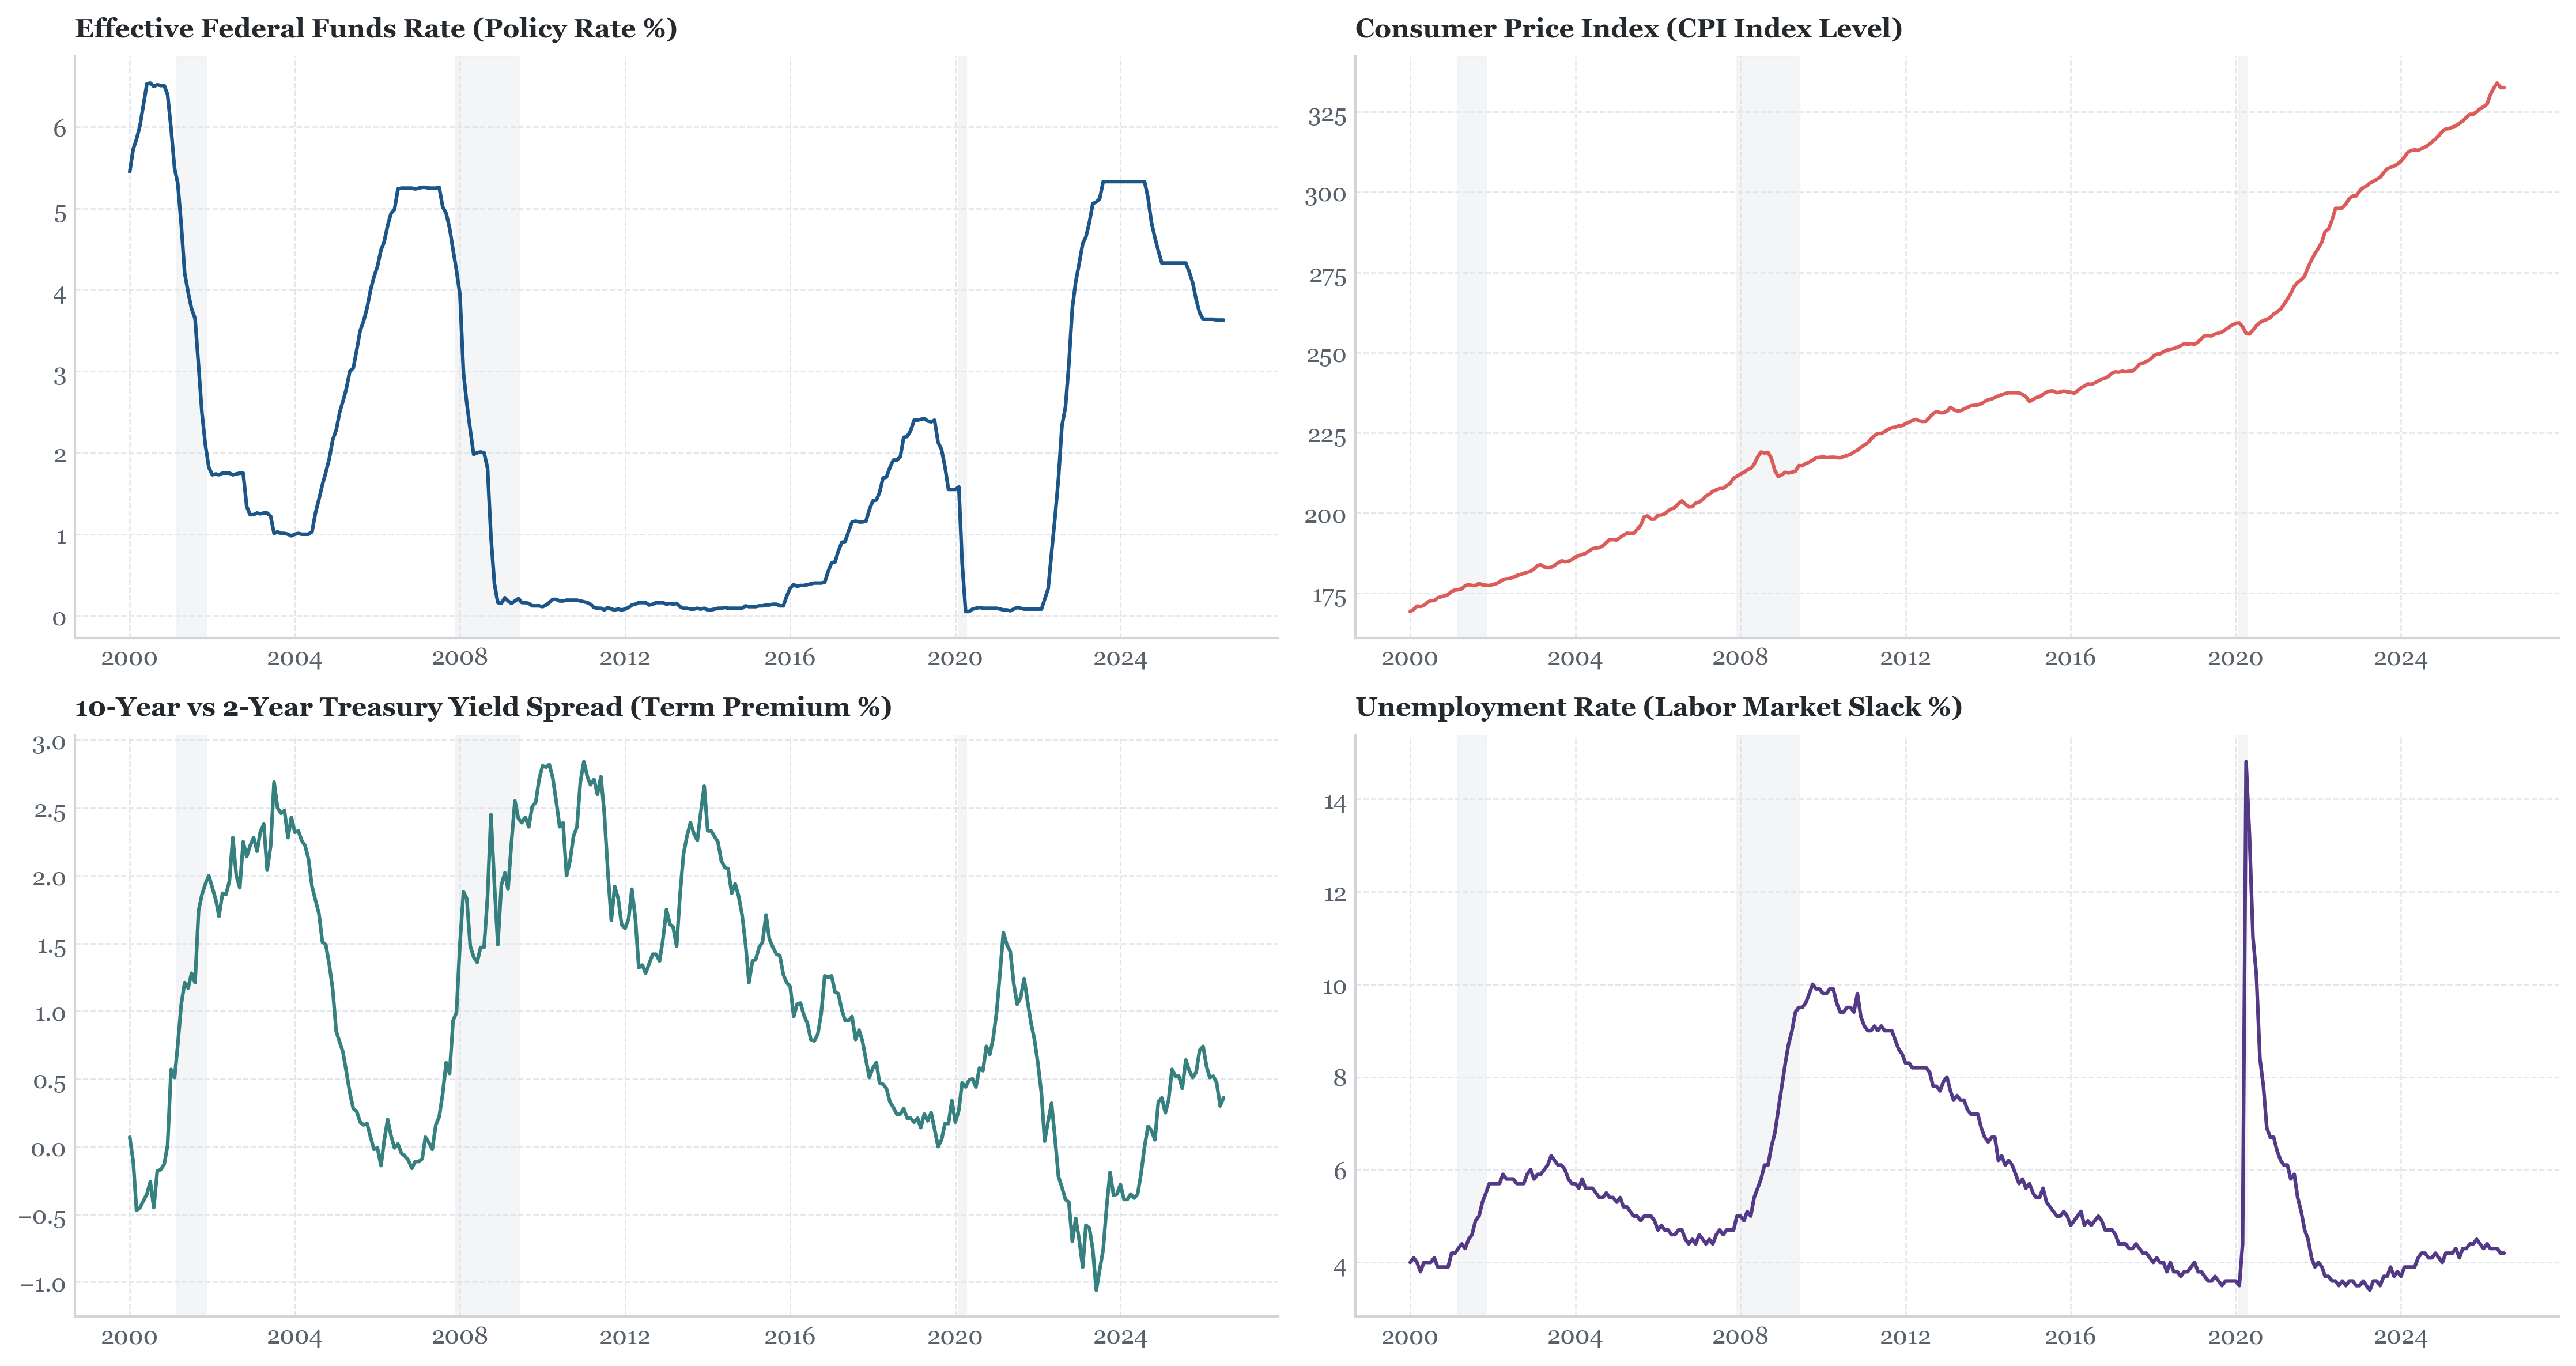

In [15]:
recessions = [
    (pd.to_datetime('2001-03-01'), pd.to_datetime('2001-11-01')),
    (pd.to_datetime('2007-12-01'), pd.to_datetime('2009-06-01')),
    (pd.to_datetime('2020-02-01'), pd.to_datetime('2020-04-01'))
]

fig, axes = plt.subplots(2, 2, figsize=(15, 8), dpi=300)
fig.patch.set_facecolor('#ffffff')

colors = ['#0f4c81', '#d9534f', '#2b7a78', '#4a2e80']
columns = ['FEDFUNDS', 'CPIAUCSL', 'T10Y2Y', 'UNRATE']
titles = [
    'Effective Federal Funds Rate (Policy Rate %)', 
    'Consumer Price Index (CPI Index Level)', 
    '10-Year vs 2-Year Treasury Yield Spread (Term Premium %)', 
    'Unemployment Rate (Labor Market Slack %)'
]

for ax, col, color, title in zip(axes.flatten(), columns, colors, titles):
    ax.plot(df.index, df[col], color=color, linewidth=1.5, alpha=0.95)
    for start, end in recessions:
        if start >= df.index.min() and end <= df.index.max():
            ax.axvspan(start, end, color='#f1f3f5', alpha=0.8, zorder=0)
    ax.set_title(title, loc='left', fontsize=11, fontweight='semibold', pad=8, color='#24292e')
    ax.grid(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#d1d5da')
    ax.spines['bottom'].set_color('#d1d5da')

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/macro_drivers_2x2.png', bbox_inches='tight', dpi=300, facecolor='#ffffff')
plt.show()

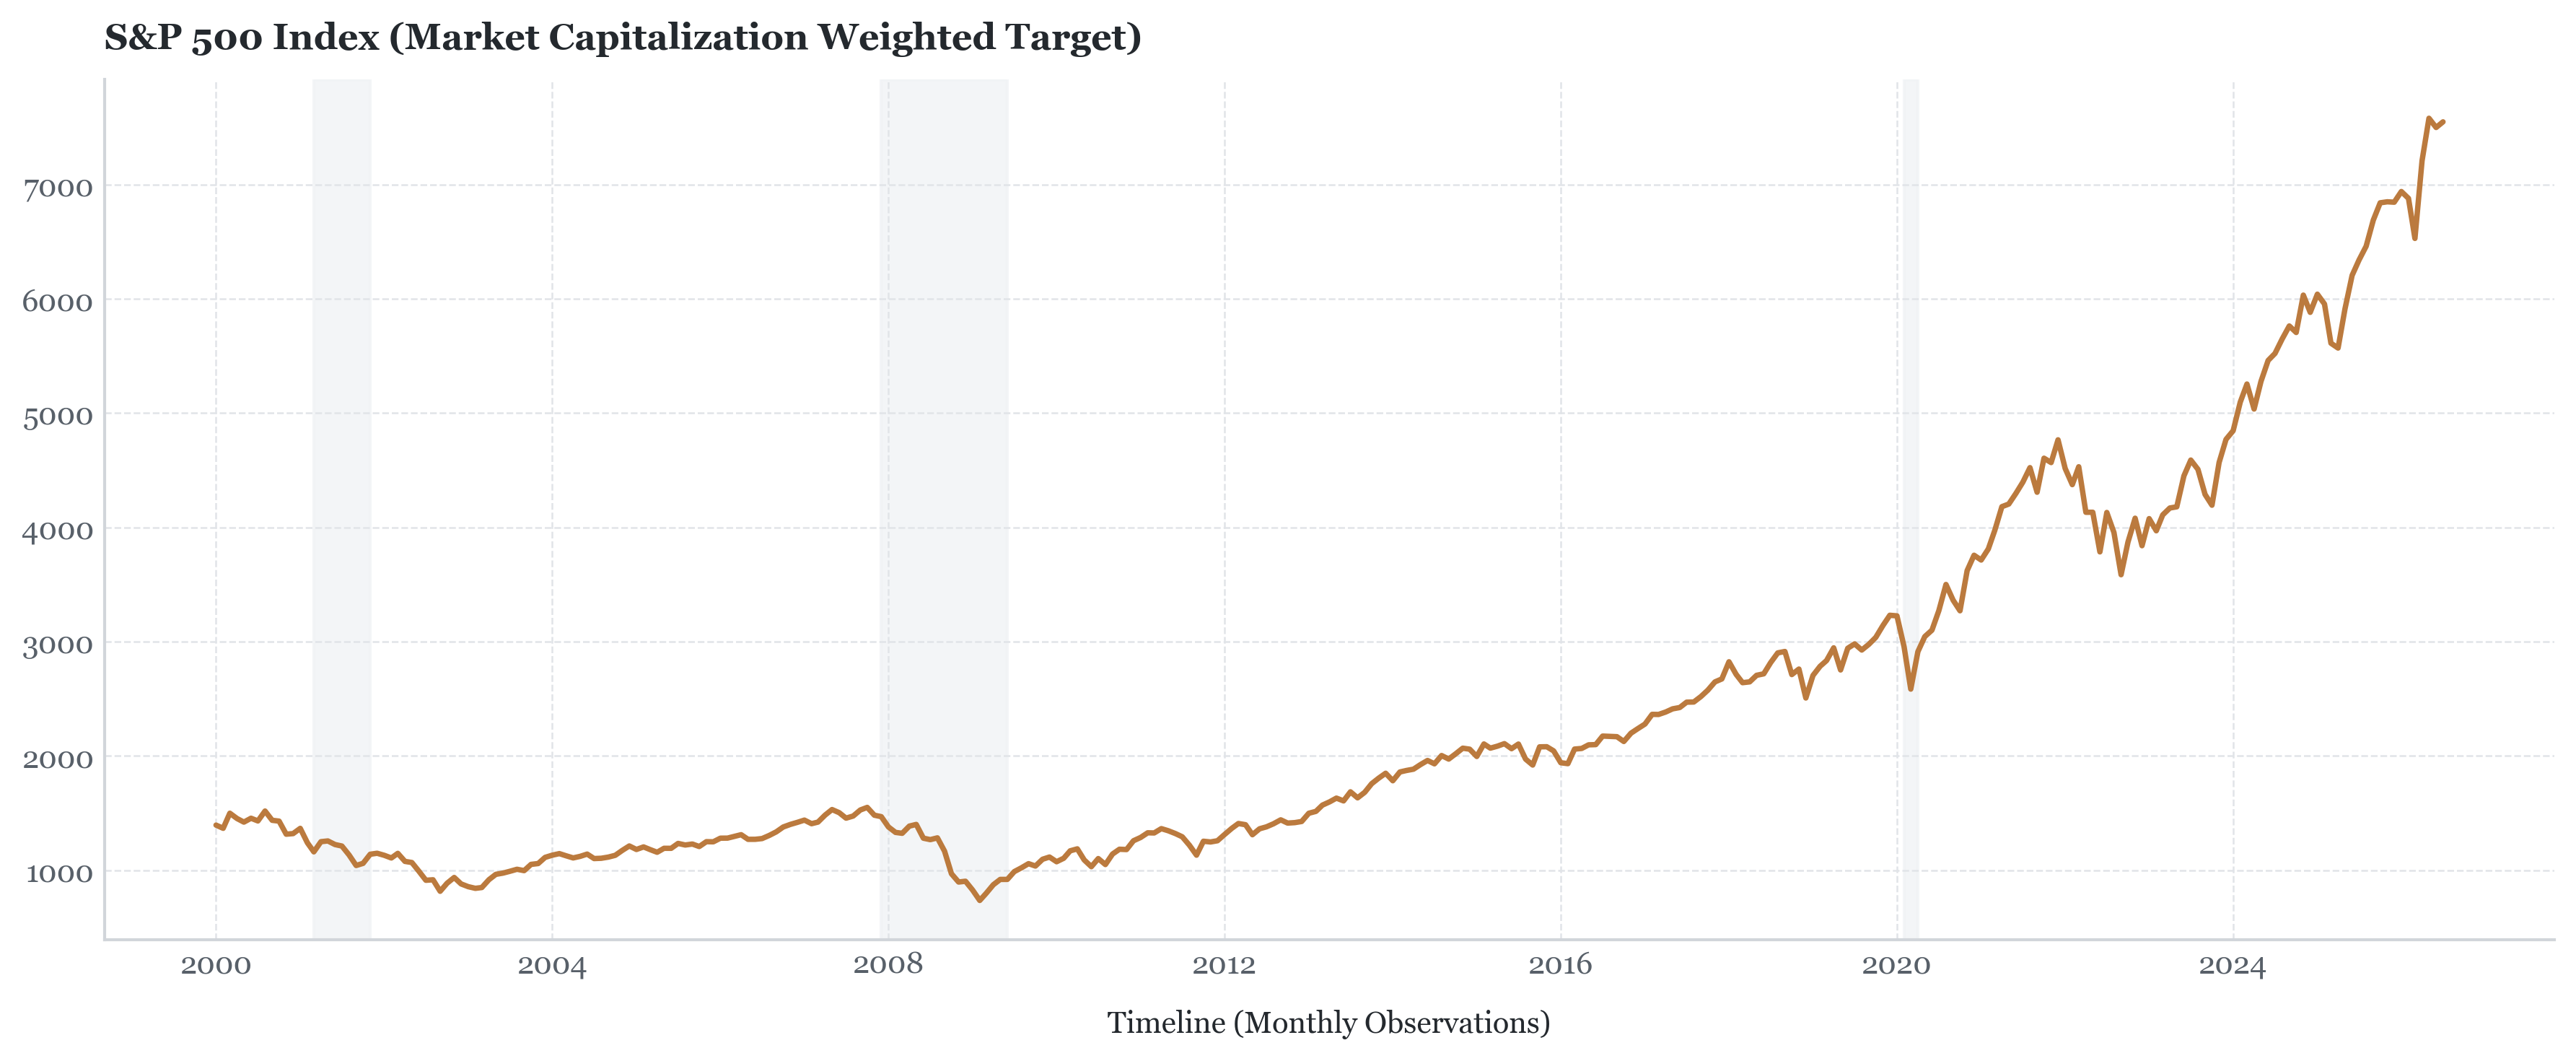

In [16]:
plt.figure(figsize=(12, 5), dpi=300)
ax = plt.gca()
fig = plt.gcf()
fig.patch.set_facecolor('#ffffff')

plt.plot(df.index, df['SP500'], color='#b87333', linewidth=1.8, alpha=0.95)

for start, end in recessions:
    if start >= df.index.min() and end <= df.index.max():
        plt.axvspan(start, end, color='#f1f3f5', alpha=0.8, zorder=0)

plt.title('S&P 500 Index (Market Capitalization Weighted Target)', loc='left', fontsize=12, fontweight='bold', pad=10, color='#24292e')
plt.grid(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#d1d5da')
ax.spines['bottom'].set_color('#d1d5da')

plt.xlabel('Timeline (Monthly Observations)', fontsize=10, labelpad=10)
plt.tight_layout()

os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/sp500_target.png', bbox_inches='tight', dpi=300, facecolor='#ffffff')
plt.show()

### 📊 Visual Trend & Regime Analysis
*   **The Power of Term Premium (`T10Y2Y`)**: The yield curve spread clearly dips below the $0\%$ threshold (inversion) shortly before the 2001, 2008, and 2020 NBER recession windows (shaded gray). This visually confirms its status as a leading economic indicator.
*   **Labor Market Lag (`UNRATE`)**: Unemployment spikes aggressively during contractions (most notably reaching a historic peak during the 2020 COVID shock) and behaves as a lagging indicator, slowly recovering long after the S&P 500 begins its new bull market.
*   **Monetary Policy Cycle (`FEDFUNDS`)**: The Federal Funds Rate displays sharp, cyclical patterns. The rapid rate hike cycle starting around 2022 to combat post-pandemic inflation is highly visible, marking a stark regime shift from the decade of near-zero interest rate policy (ZIRP).

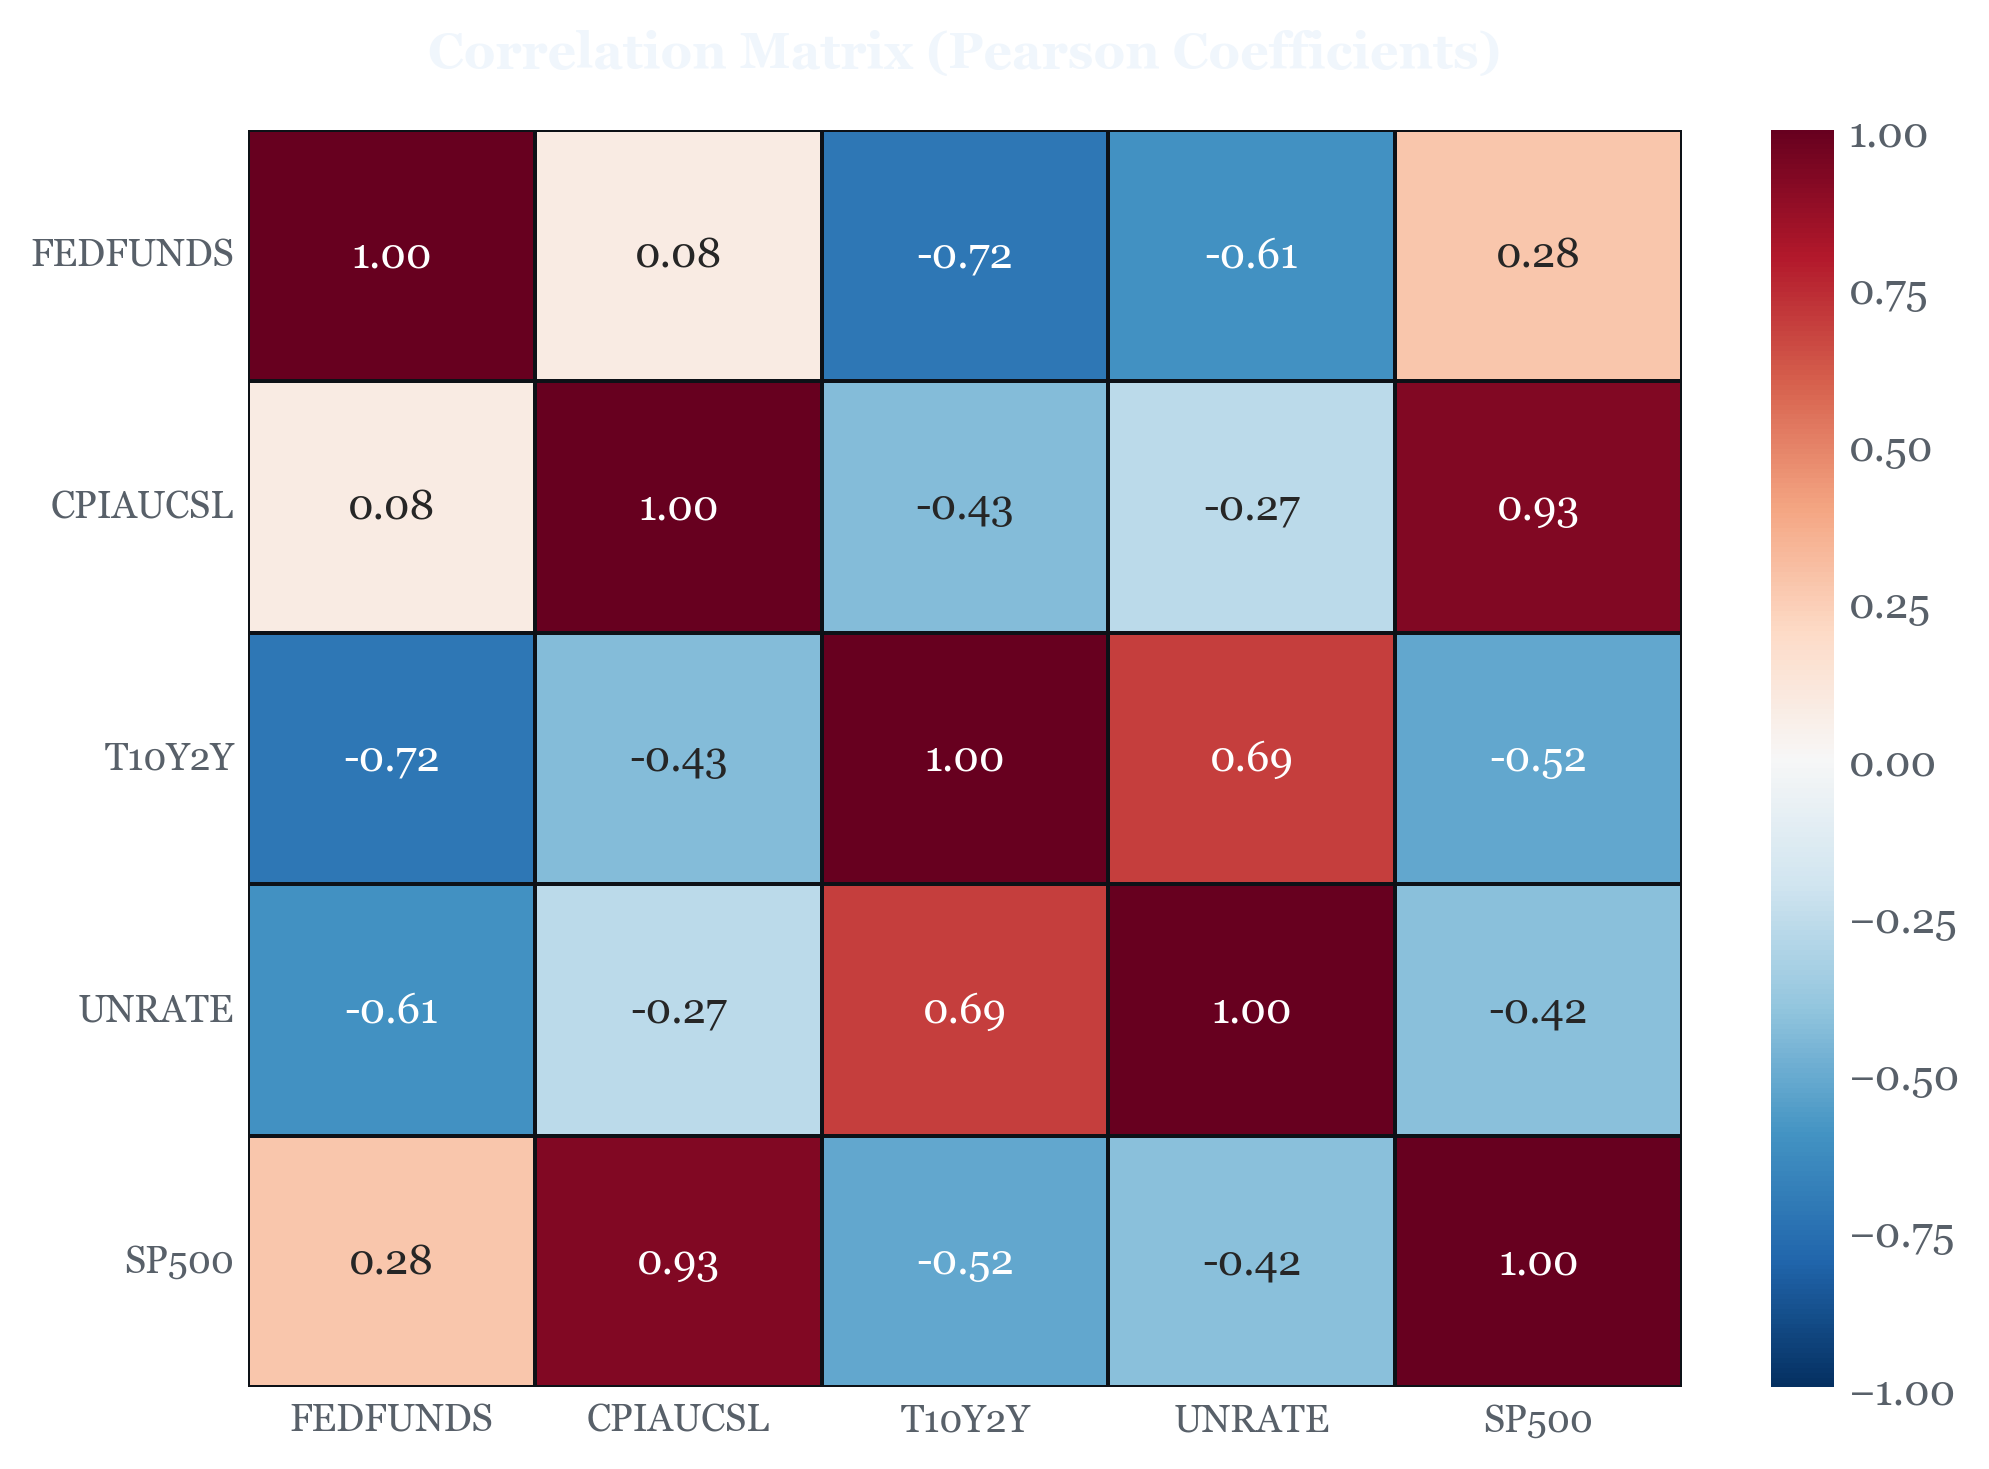

In [18]:
plt.figure(figsize=(7, 5), dpi=300)
fig = plt.gcf()
fig.patch.set_facecolor("#ffffff")

corr_matrix = df.corr()
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='RdBu_r', 
    vmin=-1, 
    vmax=1, 
    fmt='.2f', 
    linewidths=0.5, 
    linecolor='#0d1117',
    cbar=True,
    annot_kws={'size': 10, 'family': 'serif'}
)

plt.title('Correlation Matrix (Pearson Coefficients)', fontsize=12, fontweight='bold', pad=15, color='#f0f6fc')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()

os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/correlation_matrix.png', bbox_inches='tight', dpi=300, facecolor='#0d1117')
plt.show()

### 🔑 Correlation Matrix Insights
*   **The Spurious Correlation Trap**: The S&P 500 (`SP500`) and the Consumer Price Index (`CPIAUCSL`) exhibit an extremely high positive correlation ($r = 0.93$). Econometrically, this is a classic warning sign of a **spurious relationship** caused by shared deterministic upward trends in non-stationary variables.
*   **Policy Interest vs. Term Premium**: `FEDFUNDS` and `T10Y2Y` share a strong negative correlation ($r = -0.72$). As the Fed hikes the policy rate, short-term yields rise faster than long-term expectations, flattening or inverting the yield curve spread.

In [12]:
print(f"{'Variable':<15} | {'ADF Statistic':<15} | {'p-value':<10} | {'Stationary?'}")
print("-" * 60)

for col in df.columns:
    result = adfuller(df[col])
    stat = result[0]
    p_val = result[1]
    is_stationary = "YES" if p_val < 0.05 else "NO"
    print(f"{col:<15} | {stat:<15.4f} | {p_val:<10.4f} | {is_stationary}")

Variable        | ADF Statistic   | p-value    | Stationary?
------------------------------------------------------------
FEDFUNDS        | -3.7184         | 0.0039     | YES
CPIAUCSL        | 1.3221          | 0.9967     | NO
T10Y2Y          | -2.9726         | 0.0375     | YES
UNRATE          | -2.9909         | 0.0358     | YES
SP500           | 3.4383          | 1.0000     | NO


In [13]:
X = df[['FEDFUNDS', 'CPIAUCSL', 'T10Y2Y', 'UNRATE']]
X_with_const = add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

# Filter out the constant row for a cleaner presentation
vif_data = vif_data[vif_data["Feature"] != "const"].reset_index(drop=True)
vif_data

,Feature,VIF
0,FEDFUNDS,2.537348
1,CPIAUCSL,1.423861
2,T10Y2Y,3.464858
3,UNRATE,2.018316


### 🔬 Econometric Diagnostics (ADF & VIF)

#### 1. Stationarity Analysis (ADF Test)
*   **Non-Stationary Covariates**: `CPIAUCSL` ($p = 0.9967$) and `SP500` ($p = 1.0000$) strongly fail to reject the null hypothesis of a unit root. Modeling these variables in their raw level format would violate standard regression assumptions and yield invalid t-statistics.
*   **Stationary Covariates**: In this specific sample, `FEDFUNDS` ($p = 0.0039$), `T10Y2Y` ($p = 0.0375$), and `UNRATE` ($p = 0.0358$) reject the unit root hypothesis at the $5\%$ significance level, exhibiting $I(0)$ behavior.
*   *Methodological Action*: To prevent spurious regressions, `SP500` will be converted to log-returns, and `CPIAUCSL` will be transformed into inflation rate differences in the next stage.

#### 2. Multicollinearity Assessment (VIF)
*   Despite strong linear correlations in the raw matrix, all independent variables in level form show **Variance Inflation Factors (VIF) below 3.5**, well below the conservative econometric threshold of 5.0. 
*   This proves that there is no severe multicollinearity threatening the stability of our linear coefficient estimates.

<div style="
height:1px;
background:linear-gradient(to right, transparent, #b0b8c1, transparent);
margin:25px 0;
"></div>